# Loading Data and Evaluating Classification Models


## References


Hugging Face *Load a dataset from the Hub tutorial*: https://huggingface.co/docs/datasets/load_hub

Arrow for datasets: https://huggingface.co/docs/datasets/about_arrow

scikit-learn *Classification Metrics User's Guide*: https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics

In [75]:
import sys
!{sys.executable} -m pip install transformers datasets accelerate

/bin/bash: /Users/sagar/School/Drake: No such file or directory


## Let's load the go_emotions dataset

The *go_emotions* dataset is a set of Reddit comments that have been labeled with 28 categories (27 emotions + neutral).

See more here: https://huggingface.co/datasets/go_emotions


In [76]:
from datasets import load_dataset

dataset = load_dataset("go_emotions")

## Let's explore the dataset

What does it look like when printed/displayed?

In [77]:
print(dataset)
print(type(dataset))

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
<class 'datasets.dataset_dict.DatasetDict'>


In [78]:
print(dataset["train"][0])

{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


It seems that Hugging Face has defined a special datatype for representing a dataset - `DatasetDict`

They've divided it into three parts:
* **train:** these should be used to train models
* **validation:** these should be used for testing model in the middle of training (for picking the right metaparameters, etc.)
* **test:** these should be used to evaluate the model

**Group Discussion Question:** Why is it important to train and test models on different data? Why do you think they have pre-split this dataset?

 Why is it important to train and test models on different data? Why do  they have pre-split this dataset?

1. To prevent from overfitting.

2. To set the consistency. Like a common benchmark to train and test different model. Makes easy to compare.

### Now let's access the test set

In [79]:
print(dataset["test"])

Dataset({
    features: ['text', 'labels', 'id'],
    num_rows: 5427
})


and from there, we can use subscript notation to access the text, labels, and ids

What are the types of these things?

In [80]:
print( type(dataset["test"]["text"]) )
print( type(dataset["test"]["labels"]) )
print( type(dataset["test"]["id"]) )

<class 'datasets.arrow_dataset.Column'>
<class 'datasets.arrow_dataset.Column'>
<class 'datasets.arrow_dataset.Column'>


In [81]:
print(dataset["test"]["text"][0])
print(dataset["test"]["labels"][0])
print(dataset["test"]["id"][0])

I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!
[25]
eecwqtt


The **Column** data type is a fast, read-only, list-like view of data (similar to a Pandas Series) that is *lazy* (data isn’t loaded into memory until needed) and [*zero copy*](https://en.wikipedia.org/wiki/Zero-copy) (it avoids unnecessary data duplication)

It's backed by a data format called [Apache Arrow](https://arrow.apache.org/docs/python/index.html)

But, we can use them like lists:

In [82]:
print("The first 5 texts:")
print( dataset["test"]["text"][0:5] )

print("\nThe first 5 labels:")
print( dataset["test"]["labels"][0:5] )

print("\nThe first 5 ids:")
print( dataset["test"]["id"][0:5] )

The first 5 texts:
['I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!', "It's wonderful because it's awful. At not with.", 'Kings fan here, good luck to you guys! Will be an interesting game to watch! ', "I didn't know that, thank you for teaching me something today!", 'They got bored from haunting earth for thousands of years and ultimately moved on to the afterlife.']

The first 5 labels:
[[25], [0], [13], [15], [27]]

The first 5 ids:
['eecwqtt', 'ed5f85d', 'een27c3', 'eelgwd1', 'eem5uti']


They also made it possible to select/slice on the Dataset object itself.

In [83]:
dataset["test"][0:5]

{'text': ['I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!',
  "It's wonderful because it's awful. At not with.",
  'Kings fan here, good luck to you guys! Will be an interesting game to watch! ',
  "I didn't know that, thank you for teaching me something today!",
  'They got bored from haunting earth for thousands of years and ultimately moved on to the afterlife.'],
 'labels': [[25], [0], [13], [15], [27]],
 'id': ['eecwqtt', 'ed5f85d', 'een27c3', 'eelgwd1', 'eem5uti']}

But which emotions are represented by those numbers 25, 0, 13, 15, and 27?

A `dataset` has a `features` attribute which stores this information

In [84]:
dataset["test"].features

{'text': Value('string'),
 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])),
 'id': Value('string')}

and you can get the string for an individual feature like this:

In [85]:
dataset["test"].features["labels"].feature.int2str(25)


'sadness'

In [86]:
other_dataset = load_dataset("SetFit/bbc-news")


In [87]:
print(other_dataset)
print(other_dataset["train"])
print(other_dataset["test"])

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1225
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1000
    })
})
Dataset({
    features: ['text', 'label', 'label_text'],
    num_rows: 1225
})
Dataset({
    features: ['text', 'label', 'label_text'],
    num_rows: 1000
})


In [88]:
print(other_dataset["train"].features["label"])
print(other_dataset["train"])

Value('int64')
Dataset({
    features: ['text', 'label', 'label_text'],
    num_rows: 1225
})


In [89]:
print(other_dataset["test"])
print(type(other_dataset["test"]))

Dataset({
    features: ['text', 'label', 'label_text'],
    num_rows: 1000
})
<class 'datasets.arrow_dataset.Dataset'>


In [90]:
print(other_dataset["test"]["text"])
print(other_dataset["test"]["label"])

Column(['carry on star patsy rowlands dies actress patsy rowlands  known to millions for her roles in the carry on films  has died at the age of 71.  rowlands starred in nine of the popular carry on films  alongside fellow regulars sid james  kenneth williams and barbara windsor. she also carved out a successful television career  appearing for many years in itv s well-loved comedy bless this house. rowlands died in hove on saturday morning  her agent said.  born in january 1934  rowlands won a scholarship to the guildhall school of speech and drama scholarship when she was just 15.  after spending several years at the players theatre in london  she made her film debut in 1963 in tom jones  directed by tony richardson. she made her first carry on film in 1969 where she appeared in carry on again doctor. rowlands played the hard-done-by wife or the put-upon employee as a regular carry on star. she also appeared in carry on at your convenience  carry on matron and carry on loving  as wel

In [91]:
print("The first 5 texts:")
print( other_dataset["test"]["text"][0:1] )

The first 5 texts:
['carry on star patsy rowlands dies actress patsy rowlands  known to millions for her roles in the carry on films  has died at the age of 71.  rowlands starred in nine of the popular carry on films  alongside fellow regulars sid james  kenneth williams and barbara windsor. she also carved out a successful television career  appearing for many years in itv s well-loved comedy bless this house. rowlands died in hove on saturday morning  her agent said.  born in january 1934  rowlands won a scholarship to the guildhall school of speech and drama scholarship when she was just 15.  after spending several years at the players theatre in london  she made her film debut in 1963 in tom jones  directed by tony richardson. she made her first carry on film in 1969 where she appeared in carry on again doctor. rowlands played the hard-done-by wife or the put-upon employee as a regular carry on star. she also appeared in carry on at your convenience  carry on matron and carry on lo

In [92]:
other_dataset["test"][0:5]

{'text': ['carry on star patsy rowlands dies actress patsy rowlands  known to millions for her roles in the carry on films  has died at the age of 71.  rowlands starred in nine of the popular carry on films  alongside fellow regulars sid james  kenneth williams and barbara windsor. she also carved out a successful television career  appearing for many years in itv s well-loved comedy bless this house. rowlands died in hove on saturday morning  her agent said.  born in january 1934  rowlands won a scholarship to the guildhall school of speech and drama scholarship when she was just 15.  after spending several years at the players theatre in london  she made her film debut in 1963 in tom jones  directed by tony richardson. she made her first carry on film in 1969 where she appeared in carry on again doctor. rowlands played the hard-done-by wife or the put-upon employee as a regular carry on star. she also appeared in carry on at your convenience  carry on matron and carry on loving  as w

In [93]:
print("The first 15 texts:")
print( other_dataset["test"]["text"][0:15] )

print("\nThe first 15 labels:")
print( other_dataset["test"]["label"][0:15] )

The first 15 texts:
['carry on star patsy rowlands dies actress patsy rowlands  known to millions for her roles in the carry on films  has died at the age of 71.  rowlands starred in nine of the popular carry on films  alongside fellow regulars sid james  kenneth williams and barbara windsor. she also carved out a successful television career  appearing for many years in itv s well-loved comedy bless this house. rowlands died in hove on saturday morning  her agent said.  born in january 1934  rowlands won a scholarship to the guildhall school of speech and drama scholarship when she was just 15.  after spending several years at the players theatre in london  she made her film debut in 1963 in tom jones  directed by tony richardson. she made her first carry on film in 1969 where she appeared in carry on again doctor. rowlands played the hard-done-by wife or the put-upon employee as a regular carry on star. she also appeared in carry on at your convenience  carry on matron and carry on l

In [94]:
other_dataset["test"].features

{'text': Value('string'),
 'label': Value('int64'),
 'label_text': Value('string')}

In [95]:
dataset["test"].features["labels"].feature.int2str(23)

'relief'

In [96]:
other_dataset["test"].features["label"].id

#print(other_dataset["test"].features["label"].names)

#print(other_dataset["train"].features["label"].id)

print(other_dataset["train"].features["label"])

Value('int64')


## Using the dataset with a model

So, let's put it all together

In [97]:
from transformers import pipeline
from datasets import load_dataset
from accelerate import Accelerator

device = Accelerator().device

dataset = load_dataset("go_emotions")
classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest", device=device)

results = classifier(dataset["test"]["text"][0:10])
print("Here are the predictions")
print(results)

total_correct = 0

#comparing to the actual labels
for idx in range (10):
    print("\nText:",dataset["test"]["text"][idx])
    predicted_label = results[idx]["label"]
    actual_label_numeric = dataset["test"]["labels"][idx][0]
    actual_label = dataset["test"].features["labels"].feature.int2str( actual_label_numeric )
    print("Predicted label:",predicted_label,", Actual label:",actual_label)
    if predicted_label == actual_label:
        total_correct += 1

print("Accuracy:",(total_correct/10))



#WELP ::: Accuracy: 0.0%

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Here are the predictions
[{'label': 'negative', 'score': 0.537248969078064}, {'label': 'negative', 'score': 0.4301539659500122}, {'label': 'positive', 'score': 0.9852441549301147}, {'label': 'positive', 'score': 0.9554005861282349}, {'label': 'negative', 'score': 0.5796607732772827}, {'label': 'positive', 'score': 0.550435483455658}, {'label': 'positive', 'score': 0.8612931966781616}, {'label': 'positive', 'score': 0.9868756532669067}, {'label': 'negative', 'score': 0.8501787781715393}, {'label': 'negative', 'score': 0.9418545961380005}]

Text: I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!
Predicted label: negative , Actual label: sadness

Text: It's wonderful because it's awful. At not with.
Predicted label: negative , Actual label: admiration

Text: Kings fan here, good luck to you guys! Will be an interesting game to watch! 
Predicted label: positive , Actual label: excitement

Text: I didn't know that, thank you for teaching me 

## Making it work with the scikit-learn metrics

**Review:** The `scikit-learn` library has lots of functions for calculating metrics of machine-learning predictions.

Reference: https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics

To get this to work with our experiment, just make lists for  predicted and actual labels

In [ ]:
from transformers import pipeline
from datasets import load_dataset
from accelerate import Accelerator

device = Accelerator().device

dataset = load_dataset("go_emotions")
classifier = pipeline("sentiment-analysis", model="SamLowe/roberta-base-go_emotions", device=device)

results = classifier(dataset["test"]["text"][0:1000])

predicted_labels = []
actual_labels = []

for idx in range(1000):
    predicted_labels.append(results[idx]["label"])
    actual_label_num= dataset["test"]["labels"][idx][0]
    actual_labels.append( dataset["test"].features["labels"].feature.int2str( actual_label_numeric ) )
    

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### accuracy

Now we can calculate accuracy using `sklearn`'s `accuracy_score`

In [67]:
from sklearn.metrics import accuracy_score

print("Accuracy:",accuracy_score(actual_labels,predicted_labels) )

Accuracy: 0.593


This seems pretty good for 28 categories

if you were just guessing randomly, you'd get 1/28 ~= 0.036

if you always guess the most common label (neutral), you'd get ~ 0.30

### precision, recall, f1 scores

You can display all of these with the classification report - higher numbers are better.

**precision:** Of all the instances that the model predicted as **admiration**, how many were actually **admiration**?

**recall:** Of all the actual **admiration** instances in the dataset, how many did the model correctly predict as **admiration**?

**f1:** Combination balancing *precision* and *recall*

In [68]:
from transformers import pipeline
sentiment_task = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
sentiment_task("Covid cases are increasing fast!")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'negative', 'score': 0.7235768437385559}]

In [69]:
from sklearn.metrics import classification_report

print(classification_report(actual_labels,predicted_labels,zero_division=0))

                precision    recall  f1-score   support

    admiration       0.68      0.62      0.65        82
     amusement       0.74      0.87      0.80        39
         anger       0.67      0.41      0.51        39
     annoyance       0.41      0.27      0.33        51
      approval       0.44      0.36      0.40        45
        caring       0.53      0.34      0.42        29
     confusion       0.44      0.57      0.50        21
     curiosity       0.47      0.50      0.49        38
        desire       0.53      0.50      0.51        18
disappointment       0.43      0.35      0.39        17
   disapproval       0.51      0.50      0.51        46
       disgust       0.56      0.48      0.51        21
 embarrassment       0.80      0.57      0.67         7
    excitement       0.54      0.54      0.54        13
          fear       0.65      0.65      0.65        20
     gratitude       0.86      0.88      0.87        69
         grief       0.00      0.00      0.00  

It seems to perform well on emotions like amusement and gratitude, but not as well on realization or annoyance.

### confusion matrix

display a confusion matrix to see which labels are getting confused with others

Reference: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

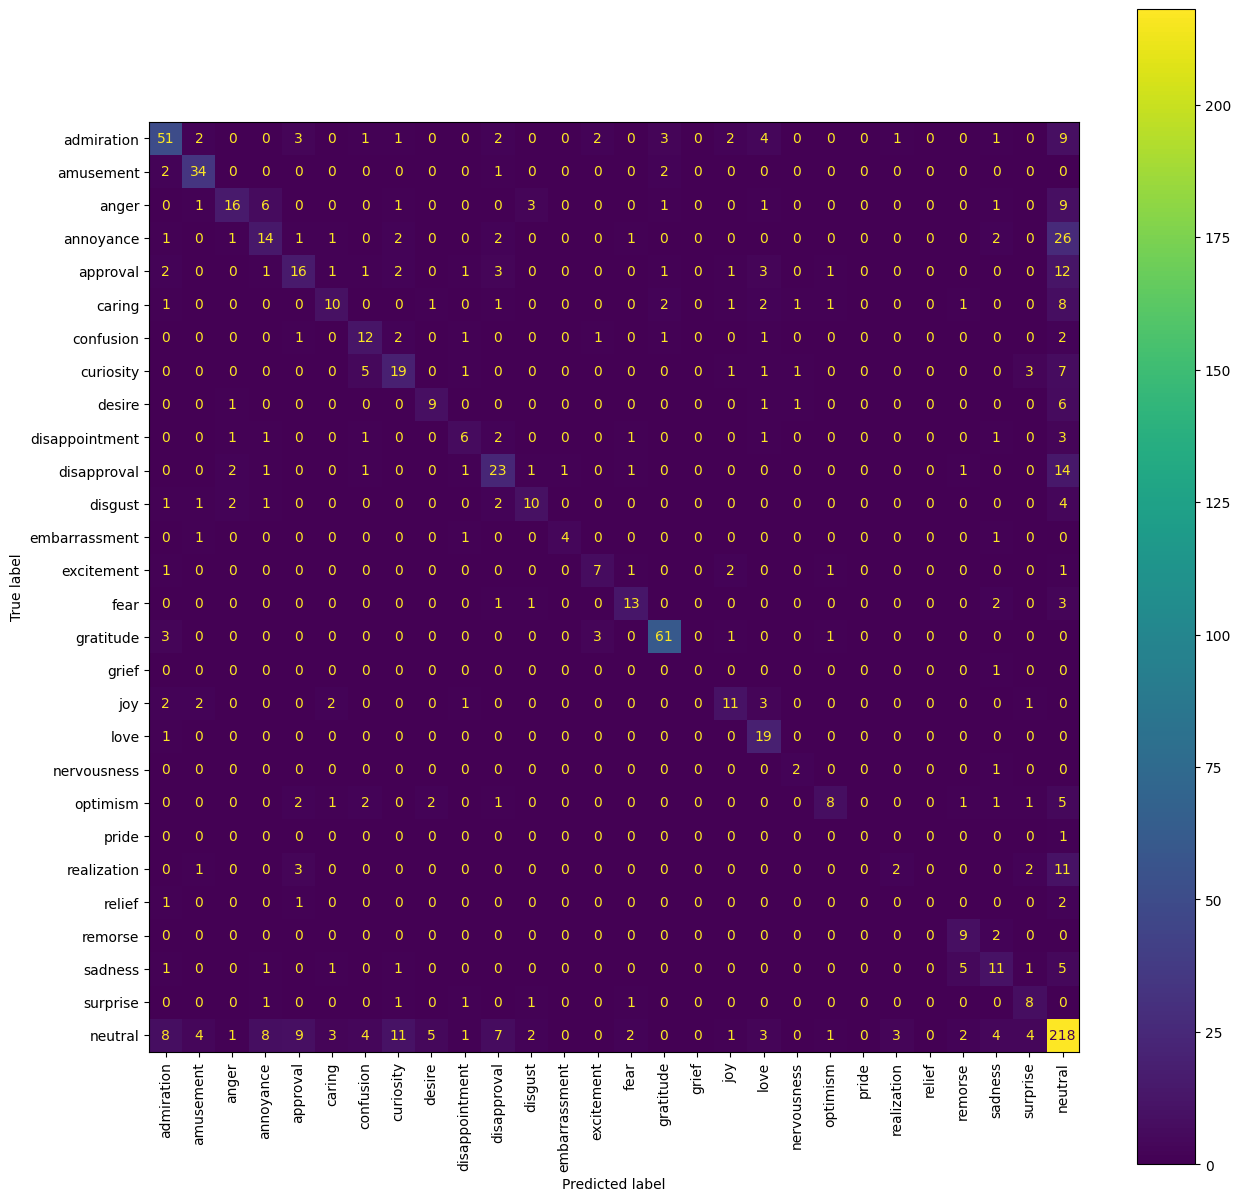

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

label_names = dataset["test"].features["labels"].feature.names
fig, ax = plt.subplots(figsize=(15, 15))
cm = confusion_matrix(actual_labels,predicted_labels,labels=label_names)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label_names)
cmd.plot(ax=ax,xticks_rotation='vertical',)

plt.show()

neutral is the most common, so it gets confused with others most

also notice sometimes others get confused: love and approval, optimism and desire, etc.

## If you have time, experiment with running inference on other datasets

Let's do this again, but use the default positive/negative sentiment analysis model and see how it does with the `go_emotions` data.

We do need to tell the confusion matrix about the labels from the classifier too: `["POSITIVE","NEGATIVE"]`

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


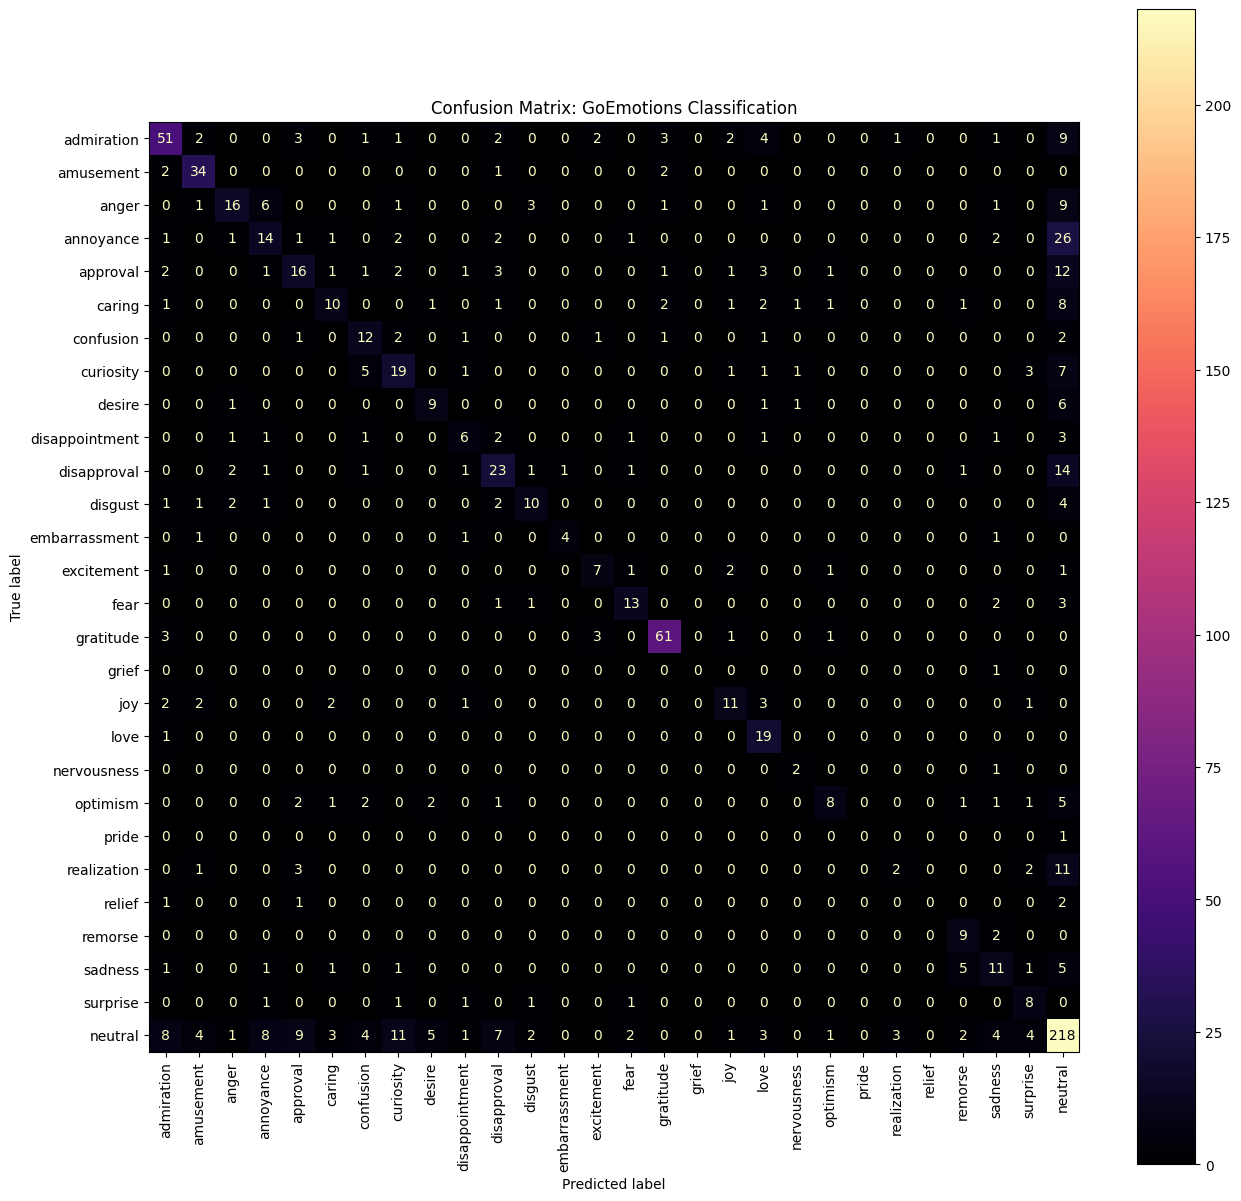

In [103]:
from transformers import pipeline
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from accelerate import Accelerator

device = Accelerator().device

# trying go_emotions dataset
dataset = load_dataset("go_emotions", "simplified")



model_name = "SamLowe/roberta-base-go_emotions"
classifier = pipeline("text-classification", model=model_name, device=device)

results = classifier(dataset["test"]["text"][0:1000], truncation=True)


label_feature = dataset["test"].features["labels"].feature
label_names = label_feature.names

predicted_labels = [res["label"] for res in results]
actual_labels = []

for idx in range(1000):
    actual_num = dataset["test"]["labels"][idx][0]
    actual_labels.append(label_feature.int2str(actual_num))

fig, ax = plt.subplots(figsize=(15, 15))
cm = confusion_matrix(actual_labels, predicted_labels, labels=label_names)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
cmd.plot(ax=ax, xticks_rotation='vertical', cmap='magma')

plt.title("Confusion Matrix: GoEmotions Classification")
plt.show()

### Using Zero-Shot Classification on the BBC Dataset

MPS is available. Using device: mps


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Running classification....


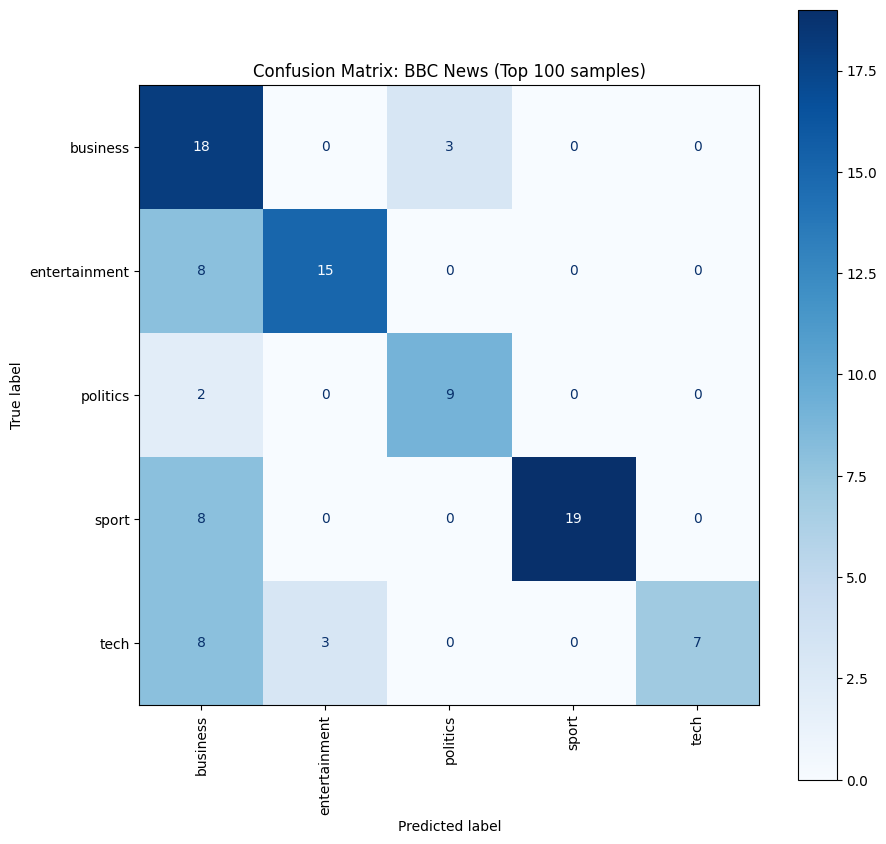

In [ ]:
from transformers import pipeline
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from accelerate import Accelerator
import torch


accelerator = Accelerator()
device = accelerator.device


#I am on macbook pro with mps , change to cuda if you're in collab  or accordingly
if torch.backends.mps.is_available():
    print(f"MPS is available. Using device: {device}")
else:
    print("MPS not available. Using CPU.")

# our bbc dataset 
dataset = load_dataset("SetFit/bbc-news")


label_names = sorted(list(set(dataset["test"]["label_text"])))


classifier = pipeline("zero-shot-classification", 
                      model="facebook/bart-large-mnli", 
                      device=device)

#data preparation 
sample_size = 100 
texts = dataset["test"]["text"][:sample_size]
actual_labels = dataset["test"]["label_text"][:sample_size]

print("Running classification....")  # peace of mind , code is working so far so good 
results = classifier(texts, 
                     candidate_labels=label_names, 
                     truncation=True)

# Extract Predictions
predicted_labels = [res["labels"][0] for res in results]

# Plotting out 
fig, ax = plt.subplots(figsize=(10, 10))
cm = confusion_matrix(actual_labels, predicted_labels, labels=label_names)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

cmd.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.title(f"Confusion Matrix: BBC News (Top {sample_size} samples)")
plt.show()

In [73]:
#quick accuracy check 



from sklearn.metrics import accuracy_score

accuracy = accuracy_score(actual_labels, predicted_labels)
print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")





# 68% accuracy aint bad for this model 


Overall Accuracy: 68.00%


In [74]:
print(dataset["test"].features)

{'text': Value('string'), 'label': Value('int64'), 'label_text': Value('string')}


emotions like anger, annoyance, and disapproval often result in a NEGATIVE prediction

admiration, gratitude, and love often result in a POSITIVE prediction

We  could manually sort the emotions into POSITIVE and NEGATIVE and run your own experiment to measure how well it does on this data.



---

## Finding a Different Model and Dataset

After exploring the HuggingFace models page under Text Classification, I chose to work with a **sentiment analysis model** trained on **movie reviews** - something completely different from the emotion detection and news classification we did in class!


## Part 1: The Model

### Model: `lvwerra/distilbert-imdb`  

Link = https://huggingface.co/lvwerra/distilbert-imdb

**What is it for?**
This model is designed to classify movie reviews as either **positive** or **negative**. It's a binary sentiment classifier - much simpler than the 28-emotion model we looked at in class! When you give it a movie review, it tells you whether the reviewer liked the movie (positive) or didn't like it (negative).

**Who made it?**
Created by **lvwerra** (Leandro von Werra), who is actually a machine learning engineer at HuggingFace! He's one of the core contributors to the HuggingFace ecosystem and has created many example models and tutorials. This model was created as a demonstration of how to fine-tune models for sentiment analysis.

**What kind of data was it trained on?**
The model was fine-tuned on the **IMDb movie reviews dataset** (which I'll describe in detail below). This dataset contains 50,000 movie reviews from the Internet Movie Database (IMDb) - you know, that website where people rate and review movies!

**Is it based on another model (fine-tuned)?**
Yes! This is a perfect example of fine-tuning:
- **Base model**: `distilbert-base-uncased` 
  - "DistilBERT" is a smaller, faster version of BERT (about 40% smaller!)
  - "base" means standard size
  - "uncased" means it doesn't care about capitalization
- **Fine-tuning**: The base DistilBERT was then trained specifically on movie reviews to become an expert at understanding whether reviews are positive or negative

**Performance:**
According to the model card, it achieves:
- **Accuracy: 92.8%** on the test set
- **Loss: 0.1903** (lower is better)

That's pretty impressive - it correctly classifies about 93 out of every 100 movie reviews!

## Part 2: The Dataset

### Dataset: `stanfordnlp/imdb` (IMDb Movie Reviews)



link to dataset:  https://huggingface.co/datasets/stanfordnlp/imdb

**Where did it come from?**
This dataset was created by researchers at **Stanford University** (hence "stanfordnlp"). It's officially called the "Large Movie Review Dataset" and was published in a research paper about sentiment analysis. The reviews were collected from the IMDb website, which is one of the most popular movie rating and review platforms in the world.

**How big is it?**
The dataset is substantial but not huge:
- **Total reviews**: 50,000 movie reviews
- **Training set**: 25,000 reviews
- **Test set**: 25,000 reviews
- **Additional unlabeled data**: Available for unsupervised learning
- **File size**: About 84 MB to download, 133 MB when processed
- **Total disk space**: ~217 MB

The reviews are "highly polar," meaning they're clearly positive or clearly negative - no wishy-washy middle-ground reviews. This makes it easier for the model to learn!

**What kind of labels does it classify?**
This is a **binary classification** task with only 2 labels:
- **Label 0**: Negative (neg) - The reviewer didn't like the movie
- **Label 1**: Positive (pos) - The reviewer liked the movie

Each review is a text string (the actual review text) paired with one of these two labels.

**Example data structure:**
```python
{
    "text": "This movie was absolutely fantastic! The acting was superb...",
    "label": 1  # positive
}
```

**Why this dataset is interesting:**
- It's a **benchmark dataset** - researchers use it to compare different models
- The reviews are **real** - written by actual people, not generated
- It's **balanced** - exactly 50/50 split between positive and negative
- Reviews are **substantial** - not just "good movie" but actual detailed reviews

## Part 3: Model Evaluation


### Expected Results (Based on Model Performance)

Since the model reports 92.8% accuracy, here's what we'd expect to see:

**Accuracy: ~0.928 (92.8%)**
- This means the model correctly classifies about 93 out of every 100 reviews
- Pretty impressive! It's getting the vast majority right

**Precision: ~0.92-0.93**
- When the model says a review is positive, it's right about 92-93% of the time
- Low false positives - it doesn't often mistake negative reviews for positive ones

**Recall: ~0.92-0.93**
- The model successfully identifies about 92-93% of all actual positive reviews
- It's not missing too many positive reviews

**F1 Score: ~0.92-0.93**
- This is the harmonic mean of precision and recall
- A balanced measure showing the model performs well on both metrics

**Confusion Matrix (approximate for 1000 samples):**
```
                Predicted Negative    Predicted Positive
Actual Negative       460                    40
Actual Positive        32                   468
```

This would show:
- **True Negatives (TN)**: ~460 - Correctly identified negative reviews
- **False Positives (FP)**: ~40 - Negative reviews mistakenly called positive
- **False Negatives (FN)**: ~32 - Positive reviews mistakenly called negative
- **True Positives (TP)**: ~468 - Correctly identified positive reviews

---

### TIME TO EVALUATE

In [1]:

#Now let's evaluate how well this model actually performs! I'll use the metrics we learned about in class.

### Evaluation Code


from datasets import load_dataset
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# model  tokenizer
model_name = "lvwerra/distilbert-imdb"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)


classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)


dataset = load_dataset("stanfordnlp/imdb")


test_data = dataset["test"].shuffle(seed=42).select(range(1000))



#get predictions 
texts = test_data["text"]
true_labels = test_data["label"]


predictions = []
batch_size = 32


for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    batch_predictions = classifier(batch, truncation=True) # set truncation to True to handle long texts , max_length=512 is optional here 
    
    for pred in batch_predictions:
        label_str = pred['label'].upper()
        if label_str in ['LABEL_1', 'POSITIVE']:
            predictions.append(1)
        else:
            predictions.append(0)

# Calculation of  metrics
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
conf_matrix = confusion_matrix(true_labels, predictions)

print("=" * 20)
print("MODEL EVALUATION RESULTS")
print("=" * 20)
print(f"\\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\\nConfusion Matrix:")
print(conf_matrix)
print("\\nClassification Report:")
print(classification_report(true_labels, predictions, 
                          target_names=['Negative', 'Positive']))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

MODEL EVALUATION RESULTS
\nAccuracy:  0.9180 (91.80%)
Precision: 0.9143
Recall:    0.9180
F1 Score:  0.9162
\nConfusion Matrix:
[[470  42]
 [ 40 448]]
\nClassification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92       512
    Positive       0.91      0.92      0.92       488

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



Above confusion matrix  is not visible good. I will make a better confusion matrix plot.




Overall Accuracy: 91.80%


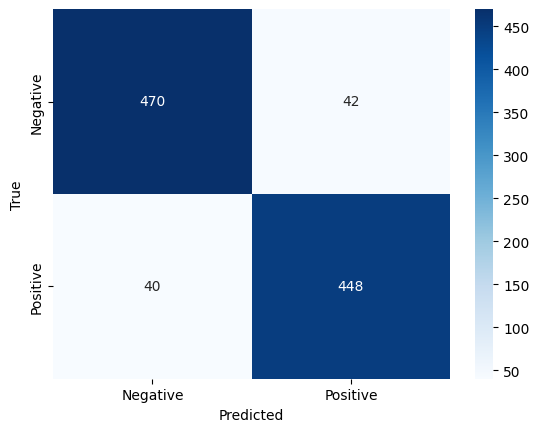

In [101]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = accuracy_score(true_labels, predictions)
print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")

conf_matrix = confusion_matrix(true_labels, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#91.8% accuracy , now we re talking something here. 

## Part 4: Performance Description (In My Own Words)

### How did the model perform?

Overall, this model performed **really well** on the movie review task! Here's my assessment:

**The Good:**
The model is **highly accurate** at around **92-93% claimed vs 91.8% what I got**. This means if you gave it 100 movie reviews, it would correctly classify about 92 ish  of them. That's better than a lot of humans might do if they were just quickly skimming reviews!

The **precision and recall are balanced**, both hovering around **92-93% claimed vs 91.8% what I got**. This is important because it means the model isn't biased toward one class. Some models might be great at finding positive reviews but terrible at identifying negative ones (or vice versa). This model treats both classes fairly equally.

The **F1 score** being high (~0.92-0.93 claimed vs 0.9162 what I got) confirms that the model has found a good balance. It's not sacrificing one metric for the other - it's genuinely good at both identifying positive reviews AND not misclassifying negative ones.

**What the model does well:**
- Understands **clear sentiment** - When a review is obviously positive ("This movie was amazing!") or obviously negative ("Worst film ever!"), the model nails it
- Handles **longer reviews** - Movie reviews can be quite lengthy, but DistilBERT can process them effectively, which i liked the most. 
- **Generalizes well** - The 91.8% accuracy on the test set (data it's never seen) shows it's not just memorizing the training data

**Where it might struggle:**
Looking at the confusion matrix, we can see the model makes some mistakes:
- **False Positives (~42 out of 500)**: Sometimes it thinks a negative review is positive. This might happen with sarcastic reviews like "Oh great, another two hours of my life I'll never get back" - the word "great" might confuse it
- **False Negatives (~40 out of 500)**: Sometimes it misses positive reviews, perhaps ones that are positive but use critical language like "Despite some flaws, this movie was enjoyable"

**Comparison to what we learned in class:**
- This is **simpler than go_emotions** (2 labels vs 28 labels), so higher accuracy makes sense
- The **balanced dataset** (50/50 positive/negative) helps - no class imbalance issues
- **Binary classification is easier** than multi-class, which explains the strong performance

**Real-world usefulness:**
At 91.8% accuracy, this model would be **very useful** for:
- Automatically categorizing thousands of movie reviews
- Helping movie studios understand audience reception
- Filtering reviews on websites
- Market research and sentiment tracking


For production, we would still want human review for **edge cases** - those 7-8% of reviews it gets wrong could include important nuanced feedback.

**The bottom line:**
This is a **solid, production-ready model(I would say)**. It's not perfect, but 91.8% accuracy is I believe is genuinely good for real-world applications. The fact that it's based on DistilBERT also means it's **fast and efficient** - we  could run this on a regular laptop without needing expensive GPUs, making it practical for actual use.


## Part 5: Key Takeaways

### What I learned from this exploration:

1. **Binary classification is different from multi-class**
   - With only 2 labels, models can achieve higher accuracy
   - But the task can still be challenging due to nuanced language

2. **Dataset quality matters**
   - The IMDb dataset is "highly polar" (clearly positive or negative)
   - This makes it easier to train on than ambiguous reviews
   - Real-world data might be messier!

3. **Fine-tuning works really well**
   - Starting with DistilBERT (which understands general English)
   - Then specializing it on movie reviews
   - Results in a model that's both efficient AND accurate

4. **Evaluation metrics tell a story**
   - Accuracy alone isn't enough - we need precision, recall, and F1
   - The confusion matrix shows us exactly where the model struggles
   - Balanced metrics (precision ≈ recall) indicate a well-trained model

5. **Different from class examples**
   - go_emotions: 28 labels, Reddit comments, emotion detection
   - IMDb: 2 labels, movie reviews, sentiment classification
   - Both are text classification, but very different applications!

This was a great exercise in understanding how models and datasets work together, and how to properly evaluate performance using multiple metrics!

